In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle
from constants import FEATURES


# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd
from signal_region import get_SR_CR_cut, compute_sr_stats
from correct_systematic_error import get_histograms, get_quantiles_with_weights

In [4]:
from scipy.stats import uniform, norm
from ks_test import max_cdf_diff
import numpy as np
from tqdm import tqdm

def truncated_normal_rejection(loc, scale, low=0, high=1, size=1, 
                               random_seed=0):
    np.random.seed(random_seed)
    samples = []
    while len(samples) < size:
        x = np.random.normal(loc=loc, scale=scale)  # proposal ~ N(0, 1)
        if low <= x <= high:
            samples.append(x)
    return np.array(samples)

# Example usage

def plot_ks_test(loc, scale):
    n_1 = 10000
    n_2 = 10000
    # loc, scale = 0, 0.1

    max_diffs_1 = []
    max_diffs_2 = []
    w_sums = []
    w2sum_over_wsum2s = []

    reps = 500
    pdf_1 = lambda x: norm.pdf(x, loc=loc, scale=scale)
    for rnd in tqdm(range(reps)):
        stats_1 = truncated_normal_rejection(loc, scale, low=0, high=1, size=n_1, random_seed=rnd)
        weights_1 = np.ones_like(stats_1)
        stats_2 = uniform.rvs(0, 1, size=n_2, random_state=rnd)
        weights_2 = pdf_1(stats_2)
        w_sums.append(np.sum(weights_2))
        w2sum_over_wsum2s.append(np.sum(weights_2)**2 / np.sum(weights_2**2))
        
        max_diffs_1.append(max_cdf_diff(stats_1[n_1 // 2:], stats_1[:n_1 // 2], 
                                        weights_1[n_1 // 2:], weights_1[:n_1 // 2]))
        max_diffs_2.append(max_cdf_diff(stats_2[n_2 // 2:], stats_2[:n_2 // 2], 
                                        weights_2[n_2 // 2:], weights_2[:n_2 // 2]))
        

    max_diffs_1 = np.array(max_diffs_1)
    max_diffs_2 = np.array(max_diffs_2)
    w_sums = np.array(w_sums)
    w2sum_over_wsum2s = np.array(w2sum_over_wsum2s)

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.hist(max_diffs_1, bins=100, density=True, label='target', histtype='step')
    ax.hist(max_diffs_2, bins=100, density=True, label=r'$N_2$', histtype='step')
    ax.hist(max_diffs_2 / np.sqrt(n_2 / w_sums), bins=100, density=True, label=r'$\sum_i w_i$', histtype='step')
    ax.hist(max_diffs_2 / np.sqrt(n_2 / w2sum_over_wsum2s), bins=100, density=True, label=r'$(\sum_i w_i)^2 / \sum_i w_i^2$', histtype='step')
    ax.legend()
    plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:08<00:00, 59.93it/s]


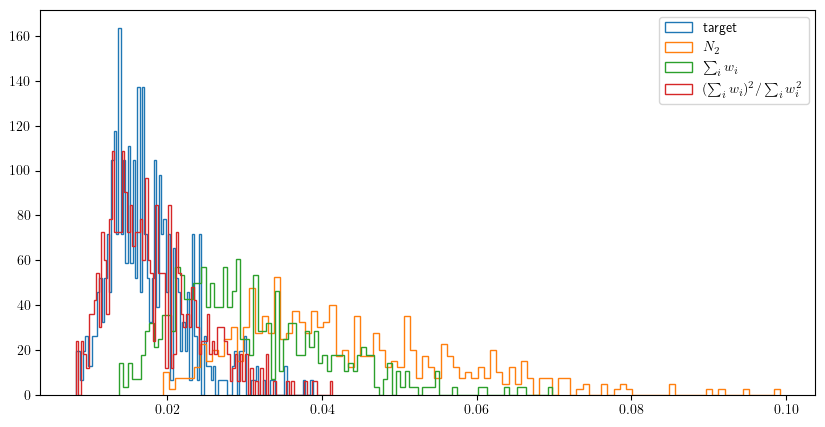

100%|██████████| 500/500 [00:05<00:00, 93.86it/s]


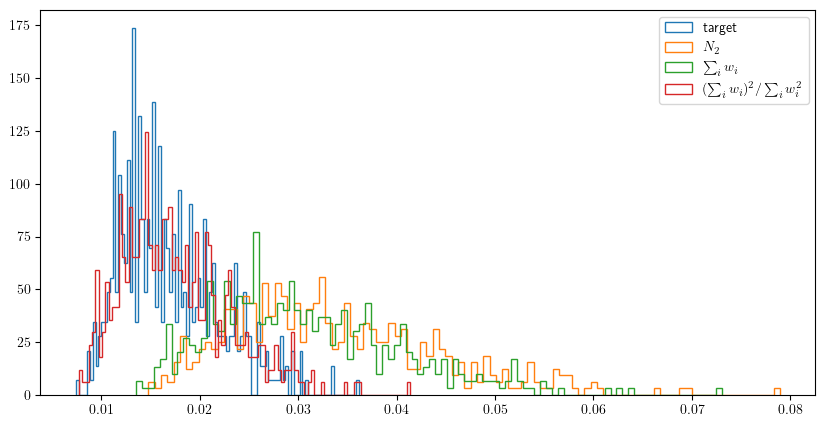

100%|██████████| 500/500 [00:06<00:00, 81.10it/s]


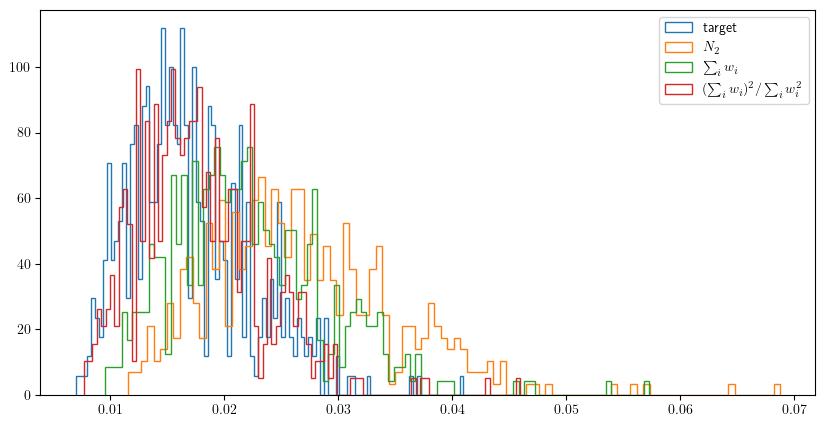

In [5]:
plot_ks_test(0, 0.1)
plot_ks_test(0.1, 0.1)
plot_ks_test(0.1, 0.2)

In [6]:
class Distribution:
    def pdf(self, x: np.ndarray) -> np.ndarray:
        pass
    
    def rvs(self, size: int) -> np.ndarray:
        pass


class NormalDistribution(Distribution):
    def __init__(self, loc: float, scale: float):
        self.loc = loc
        self.scale = scale

    def pdf(self, x: np.ndarray) -> np.ndarray:
        return (2 * np.pi * self.scale ** 2) ** -0.5 * np.exp(-0.5 * (x - self.loc) ** 2 / self.scale ** 2)
    
    def rvs(self, size: int) -> np.ndarray:
        return np.random.normal(self.loc, self.scale, size)
    
class TruncatedNormalDistribution(Distribution):
    def __init__(self, loc: float, scale: float, low: float, high: float):
        self.loc = loc
        self.scale = scale
        self.low = low
        self.high = high
        
        self.mass = norm.cdf(self.high, self.loc, self.scale) - norm.cdf(self.low, self.loc, self.scale)
        
    def pdf(self, x: np.ndarray) -> np.ndarray:
        return np.where((self.low <= x) & (x <= self.high), 
                        (2 * np.pi * self.scale ** 2) ** -0.5 * np.exp(-0.5 * (x - self.loc) ** 2 / self.scale ** 2), 
                        0) / self.mass
    
    def rvs(self, size: int, random_seed: int = None) -> np.ndarray:
        return truncated_normal_rejection(self.loc, self.scale, self.low, self.high, size, random_seed)
        
    
class UniformDistribution(Distribution):
    def __init__(self, low: float, high: float):
        self.low = low
        self.high = high

    def pdf(self, x: np.ndarray) -> np.ndarray:
        return np.where((self.low <= x) & (x <= self.high), 1 / (self.high - self.low), 0)
    
    def rvs(self, size: int) -> np.ndarray:
        return np.random.uniform(self.low, self.high, size)


In [7]:
from scipy import stats

def plot_ks_test(dist_1: Distribution, 
                 dist_2: Distribution):
    n_1 = 10000
    n_2 = 10000
    # loc, scale = 0, 0.1

    max_diffs_1 = []
    max_diffs_2 = []
    w_sums = []
    w2sum_over_wsum2s = []

    reps = 500
    for _ in tqdm(range(reps)):
        stats_1 = dist_1.rvs(size=n_1)
        weights_1 = np.ones_like(stats_1)
        stats_2 = dist_2.rvs(size=n_2)
        weights_2 = dist_1.pdf(stats_2) / dist_2.pdf(stats_2)
        w_sums.append(np.sum(weights_2))
        w2sum_over_wsum2s.append(np.sum(weights_2)**2 / np.sum(weights_2**2))
        
        max_diffs_1.append(max_cdf_diff(stats_1[n_1 // 2:], stats_1[:n_1 // 2], 
                                        weights_1[n_1 // 2:], weights_1[:n_1 // 2]))
        max_diffs_2.append(max_cdf_diff(stats_2[n_2 // 2:], stats_2[:n_2 // 2], 
                                        weights_2[n_2 // 2:], weights_2[:n_2 // 2]))
        

    max_diffs_1 = np.array(max_diffs_1)
    max_diffs_2 = np.array(max_diffs_2)
    w_sums = np.array(w_sums)
    w2sum_over_wsum2s = np.array(w2sum_over_wsum2s)

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.hist(max_diffs_1, bins=100, density=True, label='target', histtype='step')
    ax.hist(max_diffs_2, bins=100, density=True, label=r'$N_2$', histtype='step')
    ax.hist(max_diffs_2 / np.sqrt(n_2 / w_sums), bins=100, density=True, label=r'$\sum_i w_i$', histtype='step')
    ax.hist(max_diffs_2 / np.sqrt(n_2 / w2sum_over_wsum2s), bins=100, density=True, label=r'$(\sum_i w_i)^2 / \sum_i w_i^2$', histtype='step')
    ax.legend()
    plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:01<00:00, 472.98it/s]


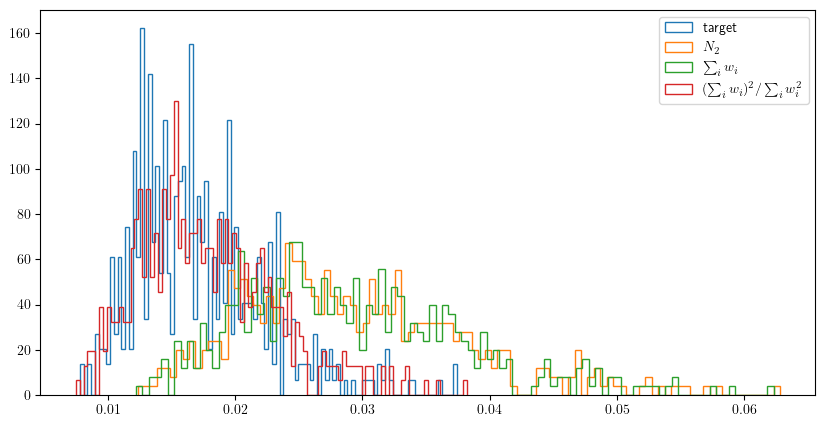

100%|██████████| 500/500 [00:00<00:00, 516.05it/s]


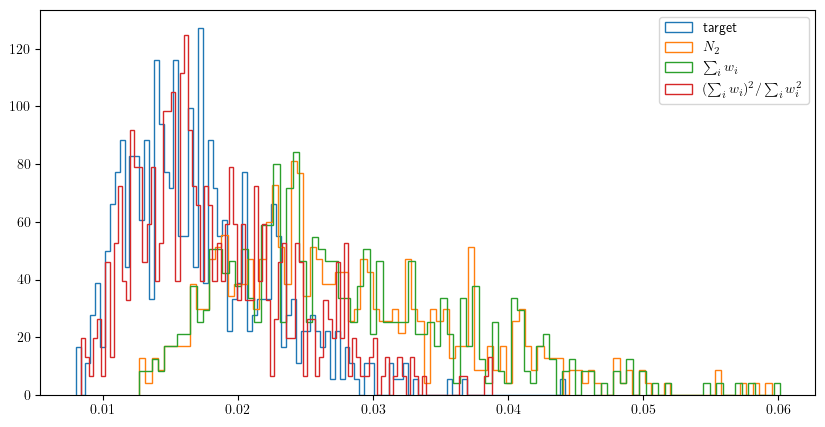

In [8]:
dist_1 = NormalDistribution(0, 0.1)
dist_2 = NormalDistribution(0.2, 0.2)
plot_ks_test(dist_1, dist_2)

dist_1 = UniformDistribution(0, 1)
dist_2 = NormalDistribution(0.5, 0.2)
plot_ks_test(dist_1, dist_2)

In [27]:
def plot_ks_tst_real(P_3b: Distribution, P_4b: Distribution, 
                     n_3b: int, 
                     reps: int = 500, 
                     title: str = None):
    
    max_diffs_weighted = []
    max_diffs_unweighted = []
    norm_0_list = []
    norm_1_list = []
    norm_2_list = []
    norm_3_list = []
    
    
    for rnd in tqdm(range(reps)):
        stats_3b = P_3b.rvs(size=n_3b, random_seed=rnd)
        weights_3b = P_4b.pdf(stats_3b) / P_3b.pdf(stats_3b)
        
        n_4b = int(np.sum(weights_3b))
        stats_4b = P_4b.rvs(size=n_4b, random_seed=2 * rnd)
        
        max_diff_weighted = max_cdf_diff(stats_3b, stats_4b, 
                                         weights_3b, np.ones_like(stats_4b))
        max_diffs_weighted.append(max_diff_weighted)
        
        stats_4b_2 = P_4b.rvs(size=n_4b, random_seed=3 * rnd)
        max_diff_unweighted = max_cdf_diff(stats_4b_2, stats_4b, 
                                           np.ones_like(stats_4b_2), np.ones_like(stats_4b))
        max_diffs_unweighted.append(max_diff_unweighted)
        
        norm_0_list.append(np.sqrt((n_3b + n_4b) / (n_3b * n_4b)))
        W1 = np.sum(weights_3b)
        norm_1_list.append(np.sqrt((W1 + n_4b) / (W1 * n_4b)))
        # W2 = np.sqrt(np.sum(weights_3b**2))
        # norm_2_list.append(np.sqrt((W2 + n_4b) / (W2 * n_4b)))
        W3 = np.sum(weights_3b)**2 / np.sum(weights_3b**2)
        norm_3_list.append(np.sqrt((W3 + n_4b) / (W3 * n_4b)))
        
    max_diffs_weighted = np.array(max_diffs_weighted)
    max_diffs_unweighted = np.array(max_diffs_unweighted)
    norm_0_list = np.array(norm_0_list)
    norm_1_list = np.array(norm_1_list)
    # norm_2_list = np.array(norm_2_list)
    norm_3_list = np.array(norm_3_list)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    if title is not None:
        ax.set_title(title)
    ax.hist(max_diffs_weighted / norm_0_list, bins=100, density=True, label='weighted', histtype='step')
    ax.hist(max_diffs_weighted / norm_1_list, bins=100, density=True, label='W', histtype='step')
    # ax.hist(max_diffs_weighted / norm_2_list, bins=100, density=True, label='W2', histtype='step')
    ax.hist(max_diffs_weighted / norm_3_list, bins=100, density=True, label='W2 / W', histtype='step')
    ax.hist(max_diffs_unweighted / norm_0_list, bins=100, density=True, label='unweighted', histtype='step')
    ax.legend()
    plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:02<00:00, 194.25it/s]


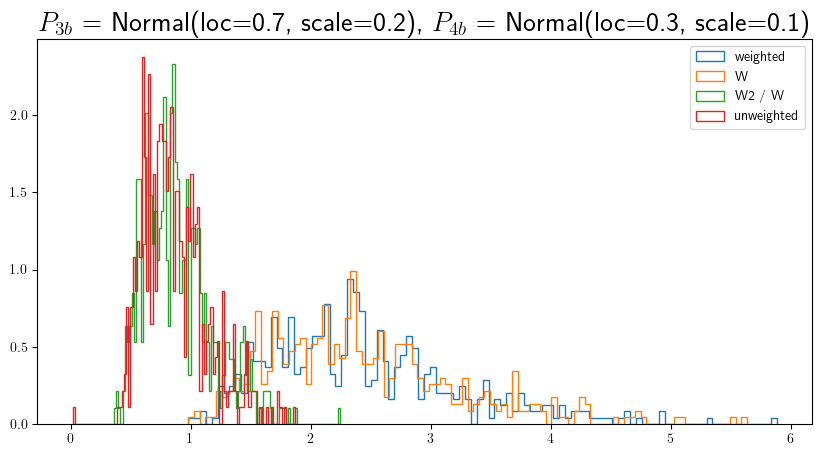

100%|██████████| 500/500 [00:02<00:00, 199.69it/s]


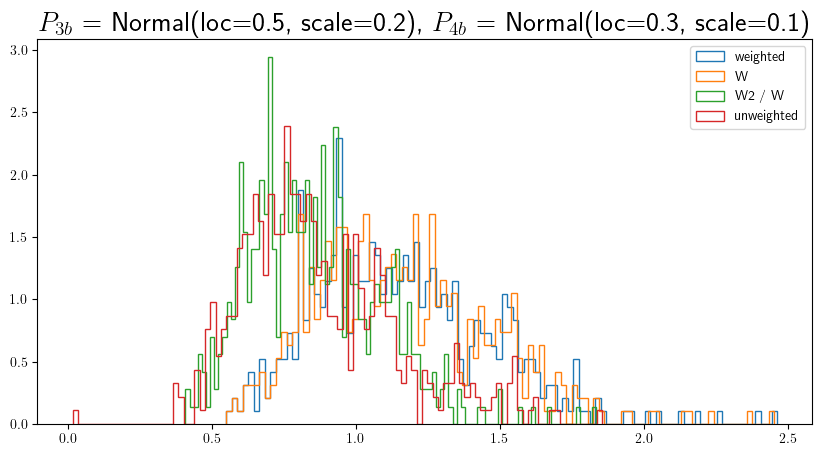

100%|██████████| 500/500 [00:02<00:00, 198.94it/s]


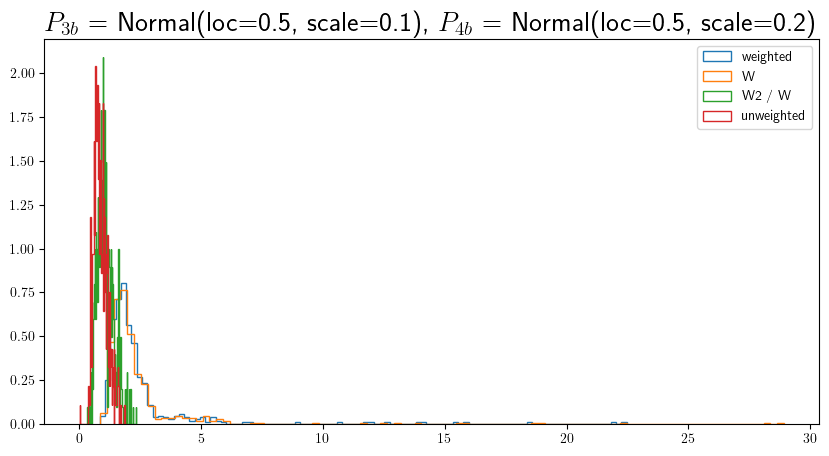

100%|██████████| 500/500 [00:02<00:00, 175.29it/s]


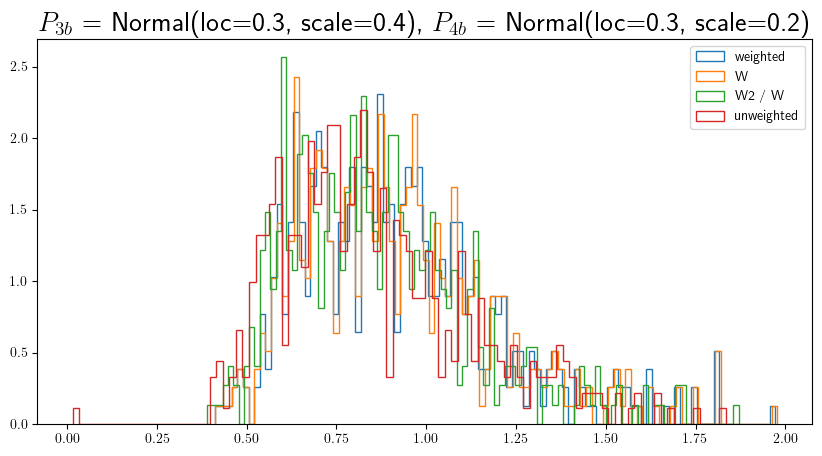

100%|██████████| 500/500 [00:02<00:00, 192.10it/s]


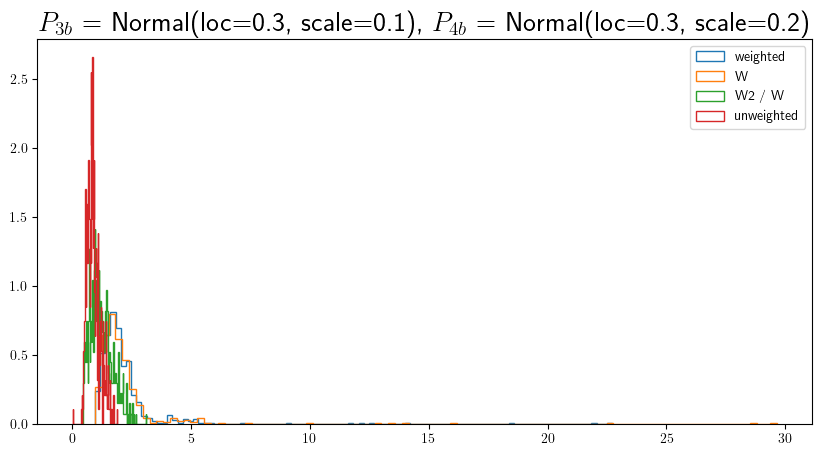

In [28]:
n_3b = 2000

P_3b = TruncatedNormalDistribution(loc=0.7, scale=0.2, low=0, high=1)
P_4b = TruncatedNormalDistribution(loc=0.3, scale=0.1, low=0, high=1)
title = r"$P_{3b}$ = Normal(loc=0.7, scale=0.2), $P_{4b}$ = Normal(loc=0.3, scale=0.1)"
plot_ks_tst_real(P_3b, P_4b, n_3b, title=title)

P_3b = TruncatedNormalDistribution(loc=0.5, scale=0.2, low=0, high=1)
P_4b = TruncatedNormalDistribution(loc=0.3, scale=0.1, low=0, high=1)
title = r"$P_{3b}$ = Normal(loc=0.5, scale=0.2), $P_{4b}$ = Normal(loc=0.3, scale=0.1)"
plot_ks_tst_real(P_3b, P_4b, n_3b, title=title)

P_3b = TruncatedNormalDistribution(loc=0.5, scale=0.1, low=0, high=1)
P_4b = TruncatedNormalDistribution(loc=0.5, scale=0.2, low=0, high=1)
title = r"$P_{3b}$ = Normal(loc=0.5, scale=0.1), $P_{4b}$ = Normal(loc=0.5, scale=0.2)"
plot_ks_tst_real(P_3b, P_4b, n_3b, title=title)

P_3b = TruncatedNormalDistribution(loc=0.3, scale=0.4, low=0, high=1)
P_4b = TruncatedNormalDistribution(loc=0.3, scale=0.2, low=0, high=1)
title = r"$P_{3b}$ = Normal(loc=0.3, scale=0.4), $P_{4b}$ = Normal(loc=0.3, scale=0.2)"
plot_ks_tst_real(P_3b, P_4b, n_3b, title=title)

P_3b = TruncatedNormalDistribution(loc=0.3, scale=0.1, low=0, high=1)
P_4b = TruncatedNormalDistribution(loc=0.3, scale=0.2, low=0, high=1)
title = r"$P_{3b}$ = Normal(loc=0.3, scale=0.1), $P_{4b}$ = Normal(loc=0.3, scale=0.2)"
plot_ks_tst_real(P_3b, P_4b, n_3b, title=title)

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:02<00:00, 192.49it/s]


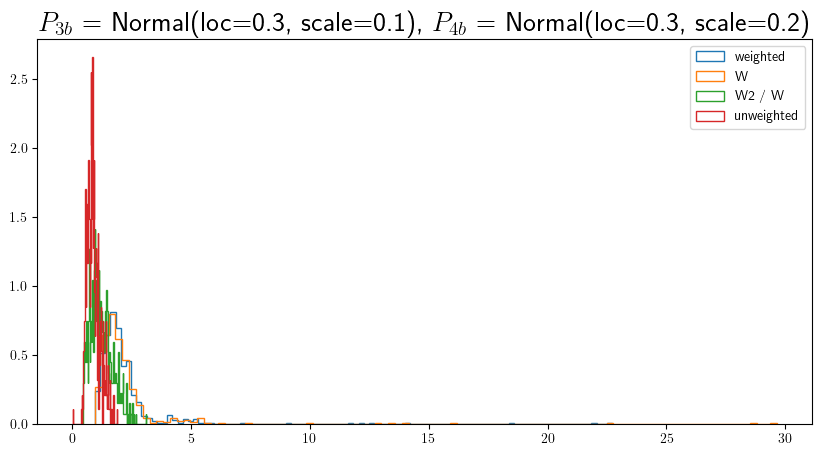

In [36]:
P_3b = TruncatedNormalDistribution(loc=0.3, scale=0.1, low=0, high=1)
P_4b = TruncatedNormalDistribution(loc=0.3, scale=0.2, low=0, high=1)
title = r"$P_{3b}$ = Normal(loc=0.3, scale=0.1), $P_{4b}$ = Normal(loc=0.3, scale=0.2)"
plot_ks_tst_real(P_3b, P_4b, n_3b, title=title)